# **Algoritmos para Bioinformática/Bioinformática 2024/2025**

By: David Pinto (up201704300@up.pt)  
Diogo Monteiro (up202108800@up.pt)  
Eduardo Oliveira (up202108690@up.pt)  

## **Assignment 2: Cancer Subtype Classification**

This project investigates the application of machine learning techniques to classify molecular subtypes of Glioblastoma Multiforme (GBM), a highly aggressive brain cancer. Specifically, the study focuses on distinguishing between the Classical (prognostically favorable) and Mesenchymal (prognostically adverse) subtypes using high-dimensional gene expression data. Through both unsupervised and supervised learning approaches, the goal is to assess whether gene expression patterns can reveal intrinsic biological structure and enable accurate subtype prediction. The insights gained from this classification task can support improved prognosis and the development of personalized treatment strategies.

### **0. Necessary Imports and Utils**

In this section we make the necessary imports and define some utility functions for our experiments.

In [58]:
!pip install -r requirements.txt

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import umap.umap_ as umap

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

from sklearn.model_selection import StratifiedKFold,cross_validate, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


def split_data(df, str_target):
    """Splits a dataframe into features (X) and target (y)"""
    X = df.drop(str_target, axis=1)
    y = df[str_target]
    return X, y

def eval(X,y,min=3,max=50,reduction='PCA',clustering='kmeans'):
    scaler = StandardScaler()
    if(clustering == 'kmeans'):
        kmeans = KMeans(n_clusters=2, random_state=42,init='k-means++',n_init=40,max_iter=300)
        if(reduction == 'PCA'):
            best_result = min
            best_V_measur = -1
            best_Completeness = -1
            best_Homogeneity = -1
            for i in range(min,max):
                pca = PCA(n_components=i, random_state=42)
                
                X_scaled = scaler.fit_transform(X)
                X_pca = pca.fit_transform(X_scaled)
                clusters_pca_kmean = kmeans.fit_predict(X_pca)
                
                if(best_Completeness < completeness_score(y, clusters_pca_kmean)):
                    best_Homogeneity = homogeneity_score(y, clusters_pca_kmean)
                    best_Completeness = completeness_score(y, clusters_pca_kmean)
                    best_V_measur = v_measure_score(y, clusters_pca_kmean)
                    best_result = i

            pca = PCA(n_components=best_result, random_state=42)       
            X_scaled = scaler.fit_transform(X)
            X_new = pca.fit_transform(X_scaled)
            cluster = kmeans.fit_predict(X_new)
        elif(reduction == 'UMAP'):
            best_result = min
            best_V_measur = -1
            best_Completeness = -1
            best_Homogeneity = -1
            for i in range(min,max):
                reducer = umap.UMAP(n_components=i, random_state=42)
                
                X_scaled = scaler.fit_transform(X)
                X_umap = reducer.fit_transform(X_scaled)
                clusters_umap_kmean = kmeans.fit_predict(X_umap)
                
                if(best_Completeness < completeness_score(y, clusters_umap_kmean)):
                    best_Homogeneity = homogeneity_score(y, clusters_umap_kmean)
                    best_Completeness = completeness_score(y, clusters_umap_kmean)
                    best_V_measur = v_measure_score(y, clusters_umap_kmean)
                    best_result = i

            reducer = umap.UMAP(n_components=best_result, random_state=42)   
            X_scaled = scaler.fit_transform(X)
            X_new = reducer.fit_transform(X_scaled)
            cluster = kmeans.fit_predict(X_new)
        else:
            return 'Error - reduction technique does not supported'
    elif(clustering == 'hierarchical'):
        hierarchical = AgglomerativeClustering(n_clusters=2)
        if(reduction == 'PCA'):
            best_result = min
            best_V_measur = -1
            best_Completeness = -1
            best_Homogeneity = -1
            for i in range(min,max):
                pca = PCA(n_components=i, random_state=42)
                
                X_scaled = scaler.fit_transform(X)
                X_pca = pca.fit_transform(X_scaled)
                clusters_pca_kmean = hierarchical.fit_predict(X_pca)
                
                if(best_Completeness < completeness_score(y, clusters_pca_kmean)):
                    best_Homogeneity = homogeneity_score(y, clusters_pca_kmean)
                    best_Completeness = completeness_score(y, clusters_pca_kmean)
                    best_V_measur = v_measure_score(y, clusters_pca_kmean)
                    best_result = i

            pca = PCA(n_components=best_result, random_state=42)       
            X_scaled = scaler.fit_transform(X)
            X_new = pca.fit_transform(X_scaled)
            cluster = hierarchical.fit_predict(X_new)
        elif(reduction == 'UMAP'):
            best_result = min
            best_V_measur = -1
            best_Completeness = -1
            best_Homogeneity = -1
            for i in range(min,max):
                reducer = umap.UMAP(n_components=i, random_state=42)
                
                X_scaled = scaler.fit_transform(X)
                X_umap = reducer.fit_transform(X_scaled)
                clusters_umap_kmean = hierarchical.fit_predict(X_umap)
                
                if(best_Completeness < completeness_score(y, clusters_umap_kmean)):
                    best_Homogeneity = homogeneity_score(y, clusters_umap_kmean)
                    best_Completeness = completeness_score(y, clusters_umap_kmean)
                    best_V_measur = v_measure_score(y, clusters_umap_kmean)
                    best_result = i

            reducer = umap.UMAP(n_components=best_result, random_state=42)   
            X_scaled = scaler.fit_transform(X)
            X_new = reducer.fit_transform(X_scaled)
            cluster = hierarchical.fit_predict(X_new)
        else:
            return 'Error - reduction technique does not supported'
    else:
        return 'Error - clustering method does not supported'

    print(f"choosed {clustering} with the reduction technique {reduction} and n_components = {best_result}")
    print(f"Homogeneity: {best_Homogeneity:.3f}")  # all clusters contain only members of a single class.
    print(f"Completeness: {best_Completeness:.3f}") # all members of a given class are assigned to the same cluster.
    print(f"V-measure: {best_V_measur:.3f}") # harmonic mean of homogeneity and completeness.
    


def print_scores(name, scores):
    mean_aux = []
    std_aux = []
    print(f"\n{name} Results:")
    for metric in scoring:
        mean = scores[f'test_{metric}'].mean()
        mean_aux.append(mean)
        std = scores[f'test_{metric}'].std()
        std_aux.append(std)
        print(f"{metric.capitalize()}: {mean:.3f} ± {std:.3f}")
    return mean_aux, std_aux

mean = []
std = []
mean_no_selector = []
std_no_selector = []


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


### Data Profiling & Preprocessing

In [59]:
df1 = pd.read_csv('./data/X_gexp.csv')
df2 = pd.read_csv('./data/y_gexp.csv')
df = pd.merge(df1, df2, on="Unnamed: 0")
df.head()

,Unnamed: 0,FSTL1,ELMO2,CREB3L1,PNMA1,MMP2,SMARCD3,PKNOX2,RALYL,ZHX3,...,PSMB9,ProSAPiP1,HCLS1,MMP9,KIAA0802,DHRS2,SGEF,PIK3IP1,CTSC,x
0,TCGA-02-0001-01,2.275179,1.873549,1.772059,2.144198,2.269443,1.742389,1.797055,1.677848,1.801352,...,2.346811,2.004333,2.213310,2.407606,2.083333,2.098461,1.680092,1.953595,2.429578,0
1,TCGA-02-0004-01,2.569520,2.085888,1.961846,2.315705,2.505400,2.226593,1.798769,1.671170,2.000942,...,2.339930,2.045828,2.285701,2.633632,1.938474,1.614437,1.760419,2.010156,2.431814,1
2,TCGA-02-0009-01,2.471492,2.030865,1.845808,2.072279,2.346815,1.783762,1.707150,1.599492,1.823480,...,2.302006,2.059862,2.130193,2.349831,1.815239,1.857933,1.675823,2.011970,2.434026,0
3,TCGA-02-0015-01,2.464403,2.094165,1.762169,2.374129,2.213562,2.209426,1.925440,1.936043,2.003743,...,2.208924,2.050555,2.213955,1.982603,2.125508,1.631955,1.881003,1.886280,2.450704,0
4,TCGA-02-0016-01,2.365457,2.188070,1.763206,2.340024,2.219210,2.308335,1.801007,1.756726,2.115714,...,2.187420,2.265522,2.192262,1.796491,1.979615,1.637215,2.182186,1.897957,2.140727,0


In [60]:
print(f"Number of Features : {df.shape[1]}")
print(f"Number of Rows : {df.shape[0]}")
print(f"Number of NaN : {df.isnull().sum().sum()}")
print(f"number of duplicates : {df.duplicated().sum()}")

Number of Features : 5002
Number of Rows : 302
Number of NaN : 0
number of duplicates : 0


The dataset does not contain any duplicate or missing values. Furthermore, the target feature is balanced, as shown in the graph below.

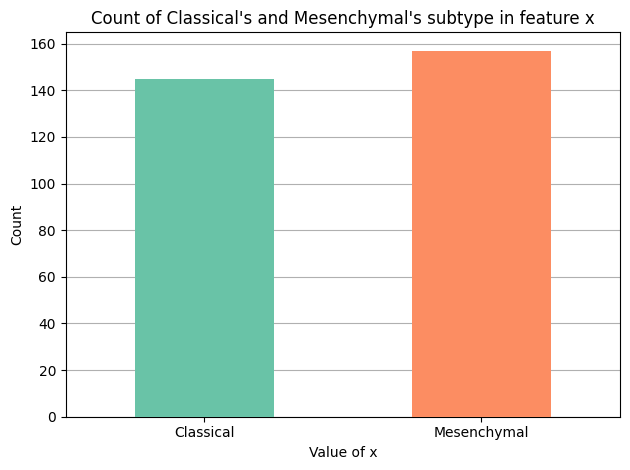

In [61]:
counts = df['x'].value_counts().sort_index()
counts.plot(kind='bar', color=['#69c3a7', '#fc8d62'], zorder=3)
plt.title('Count of Classical\'s and Mesenchymal\'s subtype in feature x')
plt.xlabel('Value of x')
plt.ylabel('Count')
plt.xticks([0, 1], ['Classical', 'Mesenchymal'], rotation=0)
plt.grid(axis='y', zorder=0)
plt.tight_layout()
plt.show()

### Unsupervised Leaning

In this section, we will test whether unsupervised learning can successfully separate the cancer subtypes using the current dataset and features. To do this, we will apply two dimensionality reduction techniques (PCA and UMAP), combined with two clustering algorithms (KMeans and hierarchical clustering).

We will also use three metrics to evaluate how well the unsupervised learning performs:

- Homogeneity: Measures whether each cluster contains only members of a single class. A high score means that the clusters are “pure” in terms of class labels.

- Completeness: Measures whether all members of a given class are assigned to the same cluster. A high score means that samples of the same class are not split across different clusters.

- V-measure: This is the harmonic mean of homogeneity and completeness, providing a balanced evaluation of the clustering quality.

In [62]:
X,y = split_data(df,'x')
X = X.drop('Unnamed: 0', axis=1)

In [63]:
eval(X,y,min=2,max=3,reduction='PCA',clustering='kmeans')

choosed kmeans with the reduction technique PCA and n_components = 2
Homogeneity: 0.014
Completeness: 0.015
V-measure: 0.015


In [64]:
eval(X,y,min=2,max=3,reduction='UMAP',clustering='kmeans')

choosed kmeans with the reduction technique UMAP and n_components = 2
Homogeneity: 0.017
Completeness: 0.019
V-measure: 0.018


In [65]:
eval(X,y,min=2,max=3,reduction='PCA',clustering='hierarchical')

choosed hierarchical with the reduction technique PCA and n_components = 2
Homogeneity: 0.004
Completeness: 0.004
V-measure: 0.004


In [66]:
eval(X,y,min=2,max=3,reduction='UMAP',clustering='hierarchical')

choosed hierarchical with the reduction technique UMAP and n_components = 2
Homogeneity: 0.003
Completeness: 0.004
V-measure: 0.004


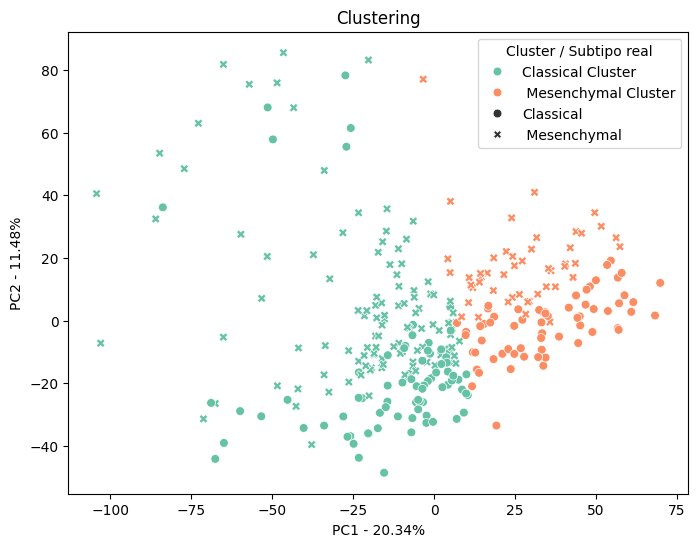

choosed kmeans with the reduction technique PCA and n_components = 2
Homogeneity: 0.014
Completeness: 0.015
V-measure: 0.015


In [67]:
scaler = StandardScaler()
kmeans = KMeans(n_clusters=2, random_state=42,init='k-means++',n_init=40,max_iter=300)
pca = PCA(n_components=2, random_state=42)

X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)
clusters_pca_kmean = kmeans.fit_predict(X_pca)

explained_variance_ratio = pca.explained_variance_ratio_ * 100
pc1 = 0
pc2 = 0
# Exibir a variância explicada por cada componente
for i, variance in enumerate(explained_variance_ratio):
    if(i==0):
        pc1 = variance
    else:
        pc2 = variance

subtype_labels = np.where(y == 0, 'Classical', ' Mesenchymal')
cluster_labels = np.where(clusters_pca_kmean == 0, 'Classical Cluster ', ' Mesenchymal Cluster')
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette='Set2', style=subtype_labels,s=40)
plt.title("Clustering")
plt.xlabel(f"PC1 - {pc1:.2f}%")
plt.ylabel(f"PC2 - {pc2:.2f}%")
plt.legend(title="Cluster / Subtipo real")
plt.show()
eval(X,y,min=2,max=3,reduction='PCA',clustering='kmeans')

Are the subtypes of cancer (Classical and Mesenchymal) recapitulated using these methods?

We tested the use of PCA and UMAP as dimensionality reduction techniques, combined with both KMeans and hierarchical clustering algorithms. For visualization purposes, we used n_components = 2, allowing us to project the data into 2D space.

The best result was achieved using PCA followed by KMeans clustering, which yielded the following evaluation scores:
Homogeneity: 0.014
Completeness: 0.015
V-measure: 0.015

These very low values indicate that the clustering does not meaningfully capture or separate the known cancer subtypes (Classical and Mesenchymal). In other words, the clusters formed do not align with the true subtype labels, suggesting that these subtypes are not well recapitulated using the unsupervised methods applied here.

### Supervised Learning

In this section, we developed a binary classifier capable of distinguishing between the Classical (prognostically favorable) and Mesenchymal (prognostically adverse) subtypes. We evaluated the following supervised models:

- Random Forest
- Support Vector Machine (SVM)
- Logistic Regression
- Naive Bayes
- K-Nearest Neighbors (KNN)

Performance was assessed using accuracy, precision, recall, and F1-score, each reported with its corresponding standard deviation to capture variability across folds.

We also performed hyperparameter optimization for each model via Grid Search to identify the parameter combinations that maximize classification performance.

Because the dataset has a limited number of samples, we employed 5-fold cross-validation (KFold = 5) to ensure robust evaluation and mitigate overfitting.

Finally, given the high dimensionality of the data (5,000 features), we applied feature selection, testing models built on the top 100, 500, 1000, 2500 and 5000 most informative features in order to reduce dimensionality and improve classifier performance.

#### Random Forest

In [68]:
scoring = ['accuracy', 'precision', 'recall', 'f1']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [69]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=100)),  # seleciona as top 100 features
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid_rf_no_selector = {
    'clf__n_estimators': [50, 100, 150, 200],
    'clf__max_depth': [None, 5, 10, 15, 20],
    'clf__max_features': ['sqrt', 'log2']
}

param_grid_rf = {
    'selector__k' : [100, 500, 1000, 2500, 5000],
    'clf__n_estimators': [50, 100, 150, 200],
    'clf__max_depth': [None, 5, 10, 15, 20],
    'clf__max_features': ['sqrt', 'log2']
}


In [70]:
grid_rf_no_selector = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf_no_selector,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)
grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

In [71]:
grid_rf_no_selector.fit(X, y)
grid_rf.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('selector', SelectKBest(k=100)),
                                       ('clf',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_depth': [None, 5, 10, 15, 20],
                         'clf__max_features': ['sqrt', 'log2'],
                         'clf__n_estimators': [50, 100, 150, 200],
                         'selector__k': [100, 500, 1000, 2500, 5000]},
             scoring='accuracy')

In [72]:
scores_rf_no_selector = cross_validate(grid_rf_no_selector.best_estimator_, X, y, cv=cv, scoring=scoring, n_jobs=-1)
scores_rf = cross_validate(grid_rf.best_estimator_, X, y, cv=cv, scoring=scoring, n_jobs=-1)

In [73]:
print("\nBest Random Forest Parameters with selector = 100:")
print(grid_rf_no_selector.best_params_)
mean_rf, std_rf = print_scores("Random Forest", scores_rf_no_selector)
mean_no_selector.append(mean_rf)
std_no_selector.append(std_rf)

print("\nBest Random Forest Parameters:")
print(grid_rf.best_params_)
mean_rf, std_rf = print_scores("Random Forest", scores_rf)
mean.append(mean_rf)
std.append(std_rf)


Best Random Forest Parameters with selector = 100:
{'clf__max_depth': None, 'clf__max_features': 'log2', 'clf__n_estimators': 100}

Random Forest Results:
Accuracy: 0.924 ± 0.016
Precision: 0.907 ± 0.038
Recall: 0.955 ± 0.032
F1: 0.929 ± 0.013

Best Random Forest Parameters:
{'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__n_estimators': 150, 'selector__k': 500}

Random Forest Results:
Accuracy: 0.937 ± 0.016
Precision: 0.924 ± 0.045
Recall: 0.962 ± 0.037
F1: 0.941 ± 0.014


#### Support Vector Machine (SVM)

In [74]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=100)),
    ('clf', SVC(kernel='rbf', C=1, gamma='scale', random_state=42))
])

param_grid_svc_no_selector = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__kernel': ['linear', 'rbf', 'poly'],
    'clf__gamma': ['scale', 'auto']
}

param_grid_svc = {
    'selector__k' : [100, 500, 1000, 2500, 5000],
    'clf__C': [0.1, 1, 10, 100],
    'clf__kernel': ['linear', 'rbf', 'poly'],
    'clf__gamma': ['scale', 'auto']
}

In [75]:
grid_svc_no_selector = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svc_no_selector,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)
grid_svc = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svc,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

In [76]:
grid_svc_no_selector.fit(X, y)
grid_svc.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('selector', SelectKBest(k=100)),
                                       ('clf', SVC(C=1, random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10, 100],
                         'clf__gamma': ['scale', 'auto'],
                         'clf__kernel': ['linear', 'rbf', 'poly'],
                         'selector__k': [100, 500, 1000, 2500, 5000]},
             scoring='accuracy')

In [77]:
scores_svm_no_selector = cross_validate(grid_svc_no_selector.best_estimator_, X, y, cv=cv, scoring=scoring)
scores_svm = cross_validate(grid_svc.best_estimator_, X, y, cv=cv, scoring=scoring)

In [78]:
print("\nBest SVM Parameters with selector = 100:")
print(grid_svc_no_selector.best_params_)
mean_svm, std_svm = print_scores("SVM", scores_svm_no_selector)
mean_no_selector.append(mean_svm)
std_no_selector.append(std_svm)

print("\nBest SVM Parameters:")
print(grid_svc.best_params_)
mean_svm, std_svm = print_scores("SVM", scores_svm)
mean.append(mean_svm)
std.append(std_svm)


Best SVM Parameters with selector = 100:
{'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

SVM Results:
Accuracy: 0.934 ± 0.031
Precision: 0.921 ± 0.022
Recall: 0.955 ± 0.056
F1: 0.937 ± 0.032

Best SVM Parameters:
{'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'selector__k': 2500}

SVM Results:
Accuracy: 0.944 ± 0.020
Precision: 0.924 ± 0.045
Recall: 0.975 ± 0.023
F1: 0.948 ± 0.017


#### Logistic Regression

In [79]:
pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=100)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr_no_selector = {
    'clf__penalty': ['l1', 'l2'],
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__solver': ['liblinear', 'saga']
}

param_grid_lr = {
    'selector__k' : [100, 500, 1000, 2500, 5000],
    'clf__penalty': ['l1', 'l2'],
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__solver': ['liblinear', 'saga'] 
}

In [80]:
grid_lr_no_selector = GridSearchCV(
    estimator=pipeline_logreg,
    param_grid=param_grid_lr_no_selector,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)
grid_lr = GridSearchCV(
    estimator=pipeline_logreg,
    param_grid=param_grid_lr,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

In [81]:
grid_lr_no_selector.fit(X, y)
grid_lr.fit(X, y)

/home/davisp/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/davisp/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/davisp/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/davisp/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/davisp/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/davisp/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:34

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('selector', SelectKBest(k=100)),
                                       ('clf',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.01, 0.1, 1, 10, 100],
                         'clf__penalty': ['l1', 'l2'],
                         'clf__solver': ['liblinear', 'saga'],
                         'selector__k': [100, 500, 1000, 2500, 5000]},
             scoring='accuracy')

In [82]:
scores_logreg_no_selector = cross_validate(grid_lr_no_selector.best_estimator_, X, y, cv=cv, scoring=scoring)
scores_logreg = cross_validate(grid_lr.best_estimator_, X, y, cv=cv, scoring=scoring)

In [83]:
print("\nBest Logistic Regression Parameters with selector = 100:")
print(grid_lr_no_selector.best_params_)
mean_lr, std_lr = print_scores("Logistic Regression", scores_logreg_no_selector)
mean_no_selector.append(mean_lr)
std_no_selector.append(std_lr)

print("\nBest Logistic Regression Parameters:")
print(grid_lr.best_params_)
mean_lr, std_lr = print_scores("Logistic Regression", scores_logreg)
mean.append(mean_lr)
std.append(std_lr)


Best Logistic Regression Parameters with selector = 100:
{'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'saga'}

Logistic Regression Results:
Accuracy: 0.917 ± 0.021
Precision: 0.923 ± 0.015
Recall: 0.917 ± 0.032
F1: 0.920 ± 0.021

Best Logistic Regression Parameters:
{'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'saga', 'selector__k': 1000}

Logistic Regression Results:
Accuracy: 0.940 ± 0.023
Precision: 0.949 ± 0.032
Recall: 0.936 ± 0.035
F1: 0.942 ± 0.022


#### Naive Bayes

In [84]:
pipeline_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=100)),
    ('clf', GaussianNB())
])

param_grid_nb_no_selector = {
    'clf__var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06]
}

param_grid_nb = {
    'selector__k' : [100, 500, 1000, 2500, 5000],
    'clf__var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06]
}

In [85]:
grid_nb_no_selector = GridSearchCV(
    estimator=pipeline_nb,
    param_grid=param_grid_nb_no_selector,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)
grid_nb = GridSearchCV(
    estimator=pipeline_nb,
    param_grid=param_grid_nb,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

In [86]:
grid_nb_no_selector.fit(X, y)
grid_nb.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('selector', SelectKBest(k=100)),
                                       ('clf', GaussianNB())]),
             n_jobs=-1,
             param_grid={'clf__var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06],
                         'selector__k': [100, 500, 1000, 2500, 5000]},
             scoring='accuracy')

In [87]:
scores_nb_no_selector = cross_validate(grid_nb_no_selector.best_estimator_, X, y, cv=cv, scoring=scoring)
scores_nb = cross_validate(grid_nb.best_estimator_, X, y, cv=cv, scoring=scoring)

In [88]:
print("\nBest Naive Bayes Parameters with selector = 100:")
print(grid_nb_no_selector.best_params_)
mean_nb, std_nb = print_scores("Naive Bayes", scores_nb_no_selector)
mean_no_selector.append(mean_nb)
std_no_selector.append(std_nb)

print("\nBest Naive Bayes Parameters:")
print(grid_nb.best_params_)
mean_nb, std_nb = print_scores("Naive Bayes", scores_nb)
mean.append(mean_nb)
std.append(std_nb)


Best Naive Bayes Parameters with selector = 100:
{'clf__var_smoothing': 1e-09}

Naive Bayes Results:
Accuracy: 0.891 ± 0.027
Precision: 0.889 ± 0.029
Recall: 0.904 ± 0.067
F1: 0.895 ± 0.030

Best Naive Bayes Parameters:
{'clf__var_smoothing': 1e-09, 'selector__k': 1000}

Naive Bayes Results:
Accuracy: 0.924 ± 0.043
Precision: 0.929 ± 0.033
Recall: 0.923 ± 0.060
F1: 0.925 ± 0.043


#### K-Nearest Neighbors (KNN)

In [89]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=100)),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

param_grid_knn_no_selector = {
    'clf__n_neighbors': [3, 5, 7, 11],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric': ['euclidean', 'manhattan']
}
param_grid_knn = {
    'selector__k' : [100, 500, 1000, 2500, 5000],
    'clf__n_neighbors': [3, 5, 7, 11],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric': ['euclidean', 'manhattan']
}

In [90]:
grid_knn_no_selector = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn_no_selector,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)
grid_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

In [91]:
grid_knn_no_selector.fit(X, y)
grid_knn.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('selector', SelectKBest(k=100)),
                                       ('clf', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'clf__metric': ['euclidean', 'manhattan'],
                         'clf__n_neighbors': [3, 5, 7, 11],
                         'clf__weights': ['uniform', 'distance'],
                         'selector__k': [100, 500, 1000, 2500, 5000]},
             scoring='accuracy')

In [92]:
scores_knn_no_selector = cross_validate(grid_knn_no_selector.best_estimator_, X, y, cv=cv, scoring=scoring)
scores_knn = cross_validate(grid_knn.best_estimator_, X, y, cv=cv, scoring=scoring)

In [93]:
print("\nBest K-Nearest Parameters with selector = 100:")
print(grid_knn_no_selector.best_params_)
mean_knn, std_knn = print_scores("K-Nearest Neighbors", scores_knn_no_selector)
mean_no_selector.append(mean_knn)
std_no_selector.append(std_knn)

print("\nBest K-Nearest Parameters:")
print(grid_knn.best_params_)
mean_knn, std_knn = print_scores("K-Nearest Neighbors", scores_knn)
mean.append(mean_knn)
std.append(std_knn)


Best K-Nearest Parameters with selector = 100:
{'clf__metric': 'manhattan', 'clf__n_neighbors': 11, 'clf__weights': 'uniform'}

K-Nearest Neighbors Results:
Accuracy: 0.910 ± 0.034
Precision: 0.922 ± 0.016
Recall: 0.904 ± 0.064
F1: 0.912 ± 0.037

Best K-Nearest Parameters:
{'clf__metric': 'manhattan', 'clf__n_neighbors': 5, 'clf__weights': 'uniform', 'selector__k': 1000}

K-Nearest Neighbors Results:
Accuracy: 0.917 ± 0.028
Precision: 0.936 ± 0.024
Recall: 0.904 ± 0.074
F1: 0.917 ± 0.033


#### Comparing Results

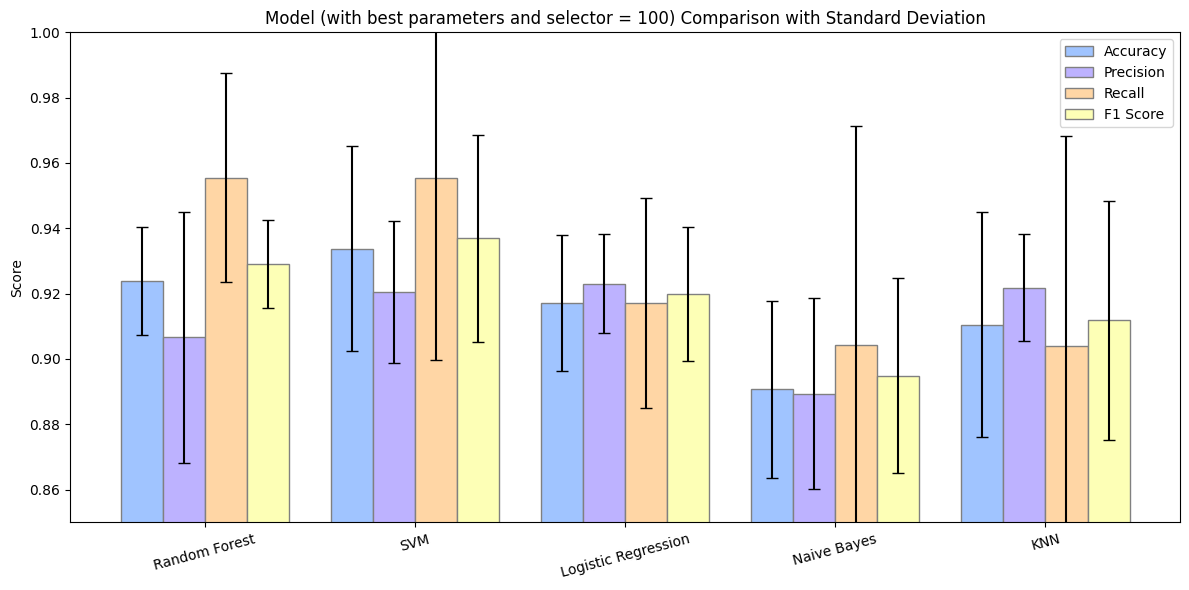

In [95]:
models = ['Random Forest', 'SVM', 'Logistic Regression', 'Naive Bayes', 'KNN']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['#A0C4FF', '#BDB2FF', '#FFD6A5', '#FDFFB6']

x = np.arange(len(models))  # Posições dos modelos no eixo x
width = 0.2  # Largura das barras

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(len(metrics)):
    ax.bar(x + i * width, [m[i] for m in mean_no_selector],
           width, yerr=[s[i] for s in std_no_selector],
           label=metrics[i],
           color=colors[i], capsize=4, edgecolor='gray')

ax.set_ylabel('Score')
ax.set_title('Model (with best parameters and selector = 100) Comparison with Standard Deviation')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models, rotation=15)
ax.set_ylim(0.85, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

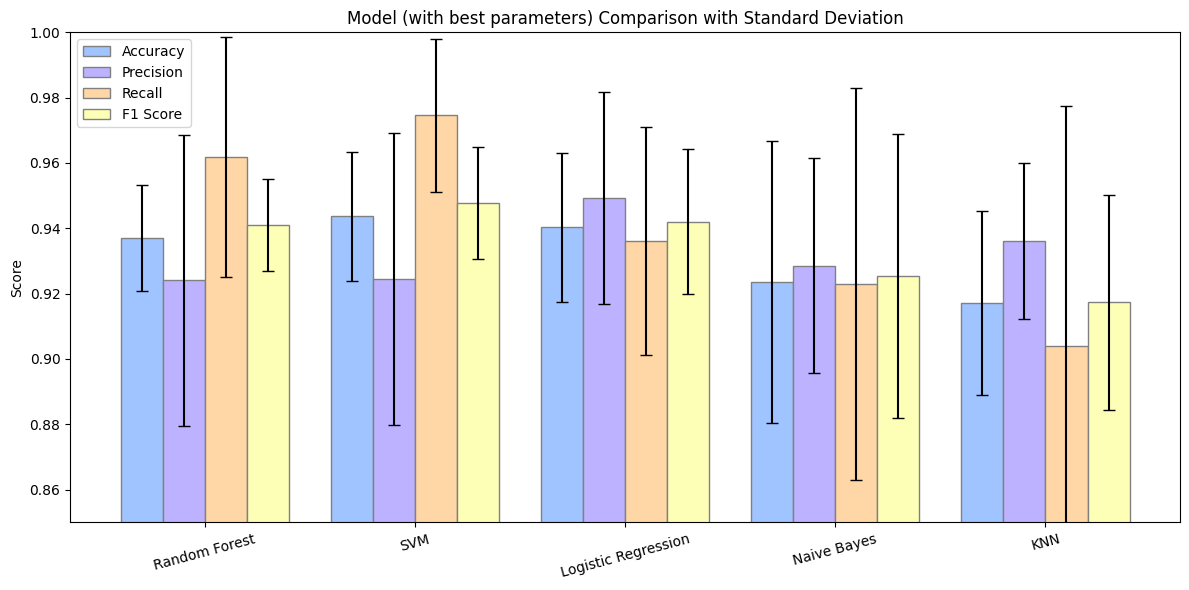

In [96]:
x = np.arange(len(models))  # Posições dos modelos no eixo x
width = 0.2  # Largura das barras

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(len(metrics)):
    ax.bar(x + i * width, [m[i] for m in mean],
           width, yerr=[s[i] for s in std],
           label=metrics[i],
           color=colors[i], capsize=4, edgecolor='gray')

ax.set_ylabel('Score')
ax.set_title('Model (with best parameters) Comparison with Standard Deviation')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models, rotation=15)
ax.set_ylim(0.85, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

The evaluation of five classification models — Random Forest, SVM, Logistic Regression, Naive Bayes, and K-Nearest Neighbors — revealed generally strong performance, with high scores across accuracy, precision, recall, and F1-score. All results were obtained using 5-fold stratified cross-validation, ensuring robustness and consistency.

Among the tested models, Support Vector Machine (SVM) achieved the best overall performance, with an accuracy of 0.944 ± 0.020 and an F1-score of 0.948 ± 0.017. These results reflect a strong balance between precision (0.924) and recall (0.975). However, it is important to note that SVM required a much larger number of features (k = 2500) to reach this level of performance.

In contrast, both Random Forest and Logistic Regression achieved competitive results using significantly fewer features — 500 and 1000, respectively — with F1-scores of 0.941 ± 0.014 and 0.942 ± 0.022. This suggests that using all available features is not necessarily beneficial. In fact, including too many features can lead to overfitting, increased variance, and potential degradation in model performance due to the inclusion of irrelevant or redundant information.

Initially, the number of selected features was not optimized via grid search, which limited model performance. After including a feature selection step with grid search, we observed notable improvements. For example, Logistic Regression initially yielded an F1-score of 0.920 ± 0.021, with the following metrics:

Logistic Regression (Initial):
- Accuracy: 0.917 ± 0.021
- Precision: 0.923 ± 0.015
- Recall: 0.917 ± 0.032
- F1: 0.920 ± 0.021

After tuning the number of features, its performance significantly improved:

Logistic Regression (After Feature Selection Grid Search):
- Accuracy: 0.940 ± 0.023
- Precision: 0.949 ± 0.032
- Recall: 0.936 ± 0.035
- F1: 0.942 ± 0.022

This example highlights the importance of proper feature selection in boosting model performance.

Models like Naive Bayes and K-Nearest Neighbors also delivered acceptable results, with F1-scores of 0.925 ± 0.043 and 0.917 ± 0.033, respectively. However, their slightly lower performance could be attributed to their simplicity and higher sensitivity to the number and type of selected features.



### Refining Unsupervised Learning 

Seeing that supervised learning achieved such good results with hyperparameter tuning, we decided to reduce the number of features using a Random Forest (the model that used fewer features) and test PCA with KMeans again to see if the homogeneity would improve.

In [97]:
selector = grid_rf.best_estimator_.named_steps['selector']
selected_indices = selector.get_support(indices=True)
X_selected = X.iloc[:, selected_indices]
print(X_selected.shape)
print(X_selected.head())


(302, 500)
      APBB2      MMP7      ZEB1    COL1A1      SELL     CNGA3      GYPC  \
0  1.786488  1.856192  1.746723  2.173766  2.012136  1.599412  2.150783   
1  2.089285  2.148095  1.959178  2.539057  2.027619  1.800009  2.338326   
2  1.778307  2.365116  1.920954  2.355175  2.002865  1.576791  2.236639   
3  2.024847  2.253762  2.217685  2.097728  1.723900  1.874730  2.420076   
4  2.086733  1.643570  2.207433  1.774010  1.739502  2.379562  1.993964   

      NTHL1    SAMSN1     POMT1  ...      UAP1      GAB1     IL2RB   DENND2D  \
0  1.843616  2.225847  1.893229  ...  2.388131  1.748370  1.976209  2.190804   
1  1.844054  2.219266  1.999704  ...  2.353954  1.710634  2.047423  1.925512   
2  2.059520  2.040249  1.840456  ...  2.276540  1.802240  1.938452  2.101692   
3  1.892321  2.200672  1.950135  ...  2.298882  1.933691  1.729204  1.701963   
4  1.926304  2.097782  2.013667  ...  2.177182  1.934453  1.734402  1.741155   

     SEMA3C      VAV1    CSF2RB     HCLS1      SGEF      

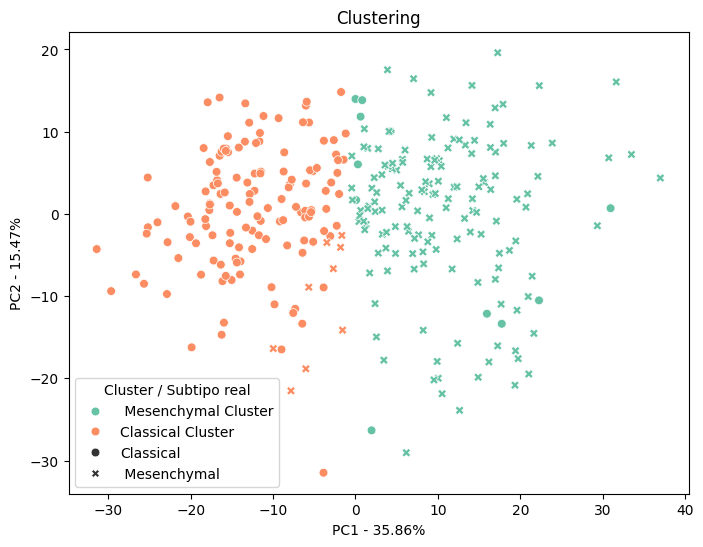

choosed kmeans with the reduction technique PCA and n_components = 2
Homogeneity: 0.648
Completeness: 0.649
V-measure: 0.648


In [98]:
scaler = StandardScaler()
kmeans = KMeans(n_clusters=2, random_state=42,init='k-means++',n_init=40,max_iter=300)
pca = PCA(n_components=2, random_state=42)

X_scaled = scaler.fit_transform(X_selected)
X_pca = pca.fit_transform(X_scaled)
clusters_pca_kmean = kmeans.fit_predict(X_pca)

explained_variance_ratio = pca.explained_variance_ratio_ * 100
pc1 = 0
pc2 = 0
# Exibir a variância explicada por cada componente
for i, variance in enumerate(explained_variance_ratio):
    if(i==0):
        pc1 = variance
    else:
        pc2 = variance
        
subtype_labels = np.where(y == 0, 'Classical', ' Mesenchymal')
cluster_labels = np.where(clusters_pca_kmean == 0, 'Classical Cluster ', ' Mesenchymal Cluster')
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette='Set2', style=subtype_labels,s=40)
plt.title("Clustering")
plt.xlabel(f"PC1 - {pc1:.2f}%")
plt.ylabel(f"PC2 - {pc2:.2f}%")
plt.legend(title="Cluster / Subtipo real")
plt.show()
eval(X_selected,y,min=2,max=3,reduction='PCA',clustering='kmeans')

The application of dimensionality reduction proved to be highly effective for the clustering problem at hand. The homogeneity score, which measures the extent to which clusters contain only data points from a single class, increased from 0.015 to 0.648. This significant improvement indicates that feature reduction eliminated noise and redundancy in the data, enabling the algorithm to identify more coherent clustering structures that align better with the original labels.

### Conclusion

In this study, despite the significant improvements achieved through feature selection, supervised learning proved to be substantially more effective at distinguishing between classes compared to unsupervised learning. The supervised models consistently delivered high performance across all evaluation metrics, demonstrating their strong ability to capture the underlying structure of the data when guided by labeled information.

Furthermore, although the supervised models achieved excellent results, there is still room for optimization. A key area for improvement lies in the feature selection process. In this work, the number of selected features was evaluated using fixed values (100, 500, 1000, 2500, and 5000). However, a more exhaustive or automated search — such as a GridSearch exploring all values between 1000 and 2500 for the SVM — could potentially yield even better results. Fine-tuning this hyperparameter alongside the model settings may enhance both accuracy and generalization while also reducing model complexity.

These findings highlight not only the strength of supervised learning in this context but also the critical importance of thoughtful feature selection in developing robust and efficient models.